## Remote Sensing classification using K-means clustering with Python

Author: Esteban Alfaro 

Email: alfaro8511@gmail.com

Date: june 2023

Website: https://estebanalfaro328753397.wordpress.com/

Original images from Google Earth

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

In [3]:
########################   CAPTURA DE LAS (X,Y, COLOR) COMO COORDENADAS DE UNA IMAGEN ###############3

In [4]:
def pez(img): #retorna una imagen en escala de grises
    if len(img.shape)==3:
        rojo=img[:,:,0] #descomponer RGB
        verde=img[:,:,1]
        azul=img[:,:,2]   
        gris=rojo*0.2125 + verde*0.7154 + azul*0.0721 #convierte a escala de gris según ecuación
    elif len(img.shape)==2:
        gris=img
    return gris

In [5]:
def ardilla(gris): #captura las x,y,z
    x=[]
    y=[]
    z=[]
    for i in range(gris.shape[0]):
        for j in range(gris.shape[1]):
            y.append(i)
            x.append(j)
            z.append(gris[i][j])
    x=np.array(x)
    y=np.array(y)
    z=np.array(z)
    R=np.stack((x,y,z))
    return R

In [30]:
def foca(gris, R): #grafica gris y x,y,z
    rata = plt.figure(figsize=(10, 20))
    ax=rata.add_subplot(111,projection='3d')
    
    ax=plt.gca()
    ax.invert_yaxis()
    
    ax.scatter(R[0,:],R[1,:],R[2,:],s=0.5)
    
    ax.view_init(elev=45,azim=-45)
    plt.show()
    
    raton = plt.figure(figsize=(8, 6))
    plt.imshow(gris,cmap='gray')
    plt.show()

In [19]:
#leer imagen satelital RGB
imagen=io.imread('imagenes_sensoresremotos/amazon1.tiff')

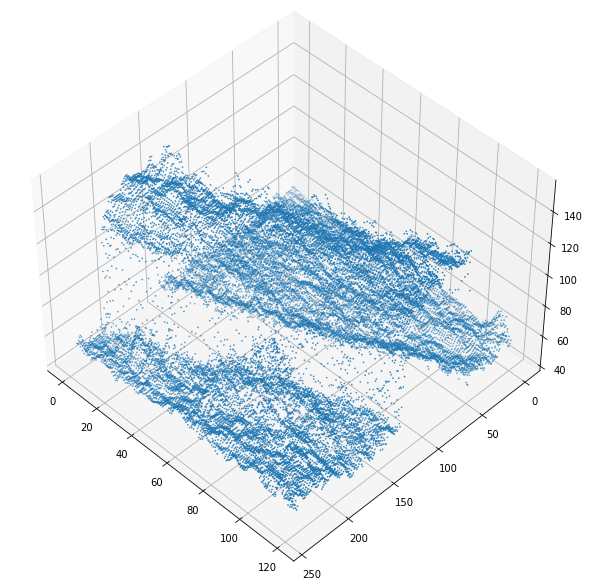

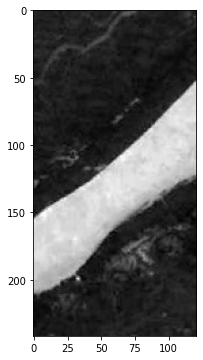

In [31]:
#principal
prueba=pez(imagen)
ptos=ardilla(prueba)
foca(prueba,ptos)

In [9]:
xx=ptos[0][:]
yy=ptos[1][:]
zz=ptos[2][:]
dodo=list(zip(xx,yy,zz))

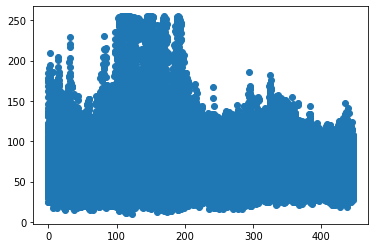

In [10]:
plt.scatter(yy,zz)

In [11]:
#agrupar x,y,z por k-means con función numpy
from sklearn.cluster import KMeans

In [12]:
gupi=2 #número de clusters
mamut=KMeans(gupi, random_state=0) #crear función kmeans
conejo = mamut.fit(dodo)  #agrupar
clusters = conejo.labels_ #etiqueta grupos con números
colores= ['red', 'blue']
centroides = conejo.cluster_centers_

/home/esteban/.local/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


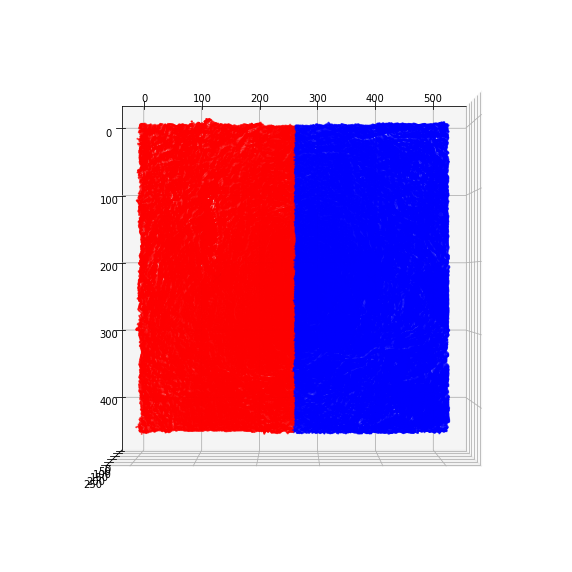

In [13]:
#graficar
pato = plt.figure(figsize=(10, 20))
ax=pato.add_subplot(111,projection='3d')
    
ax=plt.gca()
ax.invert_yaxis()   
ax.scatter(xx,yy,zz,c=[colores[label] for label in clusters],s=1)
ax.scatter(centroides[:,0], centroides[:,1],centroides[:,2],s=70,marker='x',color='black',alpha=1)
    
ax.view_init(elev=90,azim=-90)
plt.show()


In [14]:

yy=ptos[1][:]
zz=ptos[2][:]
dodo=list(zip(yy,zz))

In [15]:
#agrupar y,z por k-means
gupi=2 #número de clusters
mamut=KMeans(gupi, random_state=0) #crear función kmeans
conejo = mamut.fit(dodo)  #agrupar
clusters = conejo.labels_ #etiqueta grupos con números
colores= ['red', 'blue']
centroides = conejo.cluster_centers_

/home/esteban/.local/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


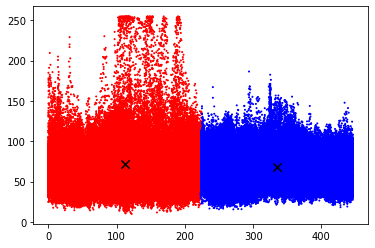

In [16]:
plt.scatter(yy,zz,c=[colores[label] for label in clusters],s=1)
plt.scatter(centroides[:,0], centroides[:,1],s=70,marker='x',color='black',alpha=1)